In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df_22 = pd.read_excel('/content/drive/MyDrive/Pós/DATATHON/base.xlsx', sheet_name='PEDE2022')

In [4]:
df_23 = pd.read_excel('/content/drive/MyDrive/Pós/DATATHON/base.xlsx', sheet_name='PEDE2023')

In [5]:
df_24 = pd.read_excel('/content/drive/MyDrive/Pós/DATATHON/base.xlsx', sheet_name='PEDE2024')

# Tratamento dos Dados

## 2022

In [6]:
df_22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [7]:
df_22.shape

(860, 42)

In [8]:
# verifica se há valores nulos nos campos
df_22.isnull().sum()

,0
RA,0
Fase,0
Turma,0
Nome,0
Ano nasc,0
Idade 22,0
Gênero,0
Ano ingresso,0
Instituição de ensino,0
Pedra 20,537


In [9]:
# verifica se há valores duplicados
df_22.duplicated().sum()

np.int64(0)

In [10]:
# remover campos que possuem muitos valores nulos ou que não serão utilizados na análise
df_22new = df_22.drop(['Fase', 'Turma', 'Nome', 'Ano nasc', 'Gênero', 'Instituição de ensino', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2',
                       'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'Rec Psicologia', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'Fase ideal',
                       'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Pedra 20', 'Pedra 21'], axis=1)

In [11]:
# incluir coluna ano
df_22new['ano'] = 2022

In [12]:
# incluir coluna IPP - aparece nas bases de 2023 e 2024
df_22new['IPP'] = 0

In [13]:
df_22new.head()

,RA,Idade 22,Ano ingresso,Pedra 22,INDE 22,IAA,IEG,IPS,IDA,IPV,IAN,Defas,ano,IPP
0,RA-1,19,2016,Quartzo,5.783,8.3,4.1,5.6,4.0,7.278,5.0,-1,2022,0
1,RA-2,17,2017,Ametista,7.055,8.8,5.2,6.3,6.8,6.778,10.0,0,2022,0
2,RA-3,17,2016,Ágata,6.591,0.0,7.9,5.6,5.6,7.556,10.0,0,2022,0
3,RA-4,17,2017,Quartzo,5.951,8.8,4.5,5.6,5.0,5.278,10.0,0,2022,0
4,RA-5,17,2016,Ametista,7.427,7.9,8.6,5.6,5.2,7.389,10.0,0,2022,0


In [14]:
df_22new.shape

(860, 14)

In [15]:
# renomear colunas
df_22new.columns = ['RA', 'IDADE', 'ANO_INGRESSO', 'PEDRA', 'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'DEFASAGEM', 'ANO', 'IPP']

In [16]:
# ordena colunas
df_22new = df_22new[['RA', 'ANO', 'ANO_INGRESSO', 'IDADE', 'PEDRA', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'DEFASAGEM']]

In [17]:
df_22new.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM
0,RA-1,2022,2016,19,Quartzo,5.783,8.3,4.1,5.6,0,4.0,7.278,5.0,-1
1,RA-2,2022,2017,17,Ametista,7.055,8.8,5.2,6.3,0,6.8,6.778,10.0,0
2,RA-3,2022,2016,17,Ágata,6.591,0.0,7.9,5.6,0,5.6,7.556,10.0,0
3,RA-4,2022,2017,17,Quartzo,5.951,8.8,4.5,5.6,0,5.0,5.278,10.0,0
4,RA-5,2022,2016,17,Ametista,7.427,7.9,8.6,5.6,0,5.2,7.389,10.0,0


## 2023

In [18]:
df_23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

In [19]:
df_23.shape

(1014, 48)

In [20]:
df_23.isnull().sum()

,0
RA,0
Fase,0
INDE 2023,83
Pedra 2023,83
Turma,0
Nome Anonimizado,0
Data de Nasc,0
Idade,0
Gênero,0
Ano ingresso,0


- há muitos campos sem informação

In [21]:
# verifica se há registros duplicados
df_23.duplicated().sum()

np.int64(0)

In [22]:
# remove campos que não serão utilizados
df_23new = df_23.drop(['Fase', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Gênero', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22',
                       'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'Rec Psicologia',
                       'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'Fase Ideal', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1'], axis=1)

In [23]:
df_23new.head()

,RA,INDE 2023,Pedra 2023,Idade,Ano ingresso,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Defasagem
0,RA-861,9.31095,Topázio,8,2023,9.5,10.0,8.13,8.4375,9.6,8.920,10.0,0
1,RA-862,8.22120,Topázio,9,2023,8.5,9.1,8.14,7.5000,8.9,8.585,5.0,-1
2,RA-863,5.92975,Quartzo,7,2023,0.0,7.6,3.14,5.9375,6.3,6.260,10.0,0
3,RA-864,7.03400,Ametista,1900-01-08 00:00:00,2023,0.0,7.6,8.14,7.5000,6.3,8.500,10.0,0
4,RA-865,8.15520,Topázio,8,2023,8.5,8.7,7.52,7.5000,7.4,7.915,10.0,0


In [24]:
# trata campo de idade
df_23new['Idade'] = (pd.to_numeric(df_23new['Idade'], errors='coerce').astype('Int64'))

In [25]:
# incluir campo de ano
df_23new['ano'] = 2023

In [26]:
# renomeia colunas
df_23new.columns = ['RA', 'INDE', 'PEDRA', 'IDADE', 'ANO_INGRESSO', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'DEFASAGEM', 'ANO']

In [27]:
# ordena colunas
df_23new = df_23new[['RA', 'ANO', 'ANO_INGRESSO', 'IDADE', 'PEDRA', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'DEFASAGEM']]

In [28]:
df_23new.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM
0,RA-861,2023,2023,8,Topázio,9.31095,9.5,10.0,8.13,8.4375,9.6,8.920,10.0,0
1,RA-862,2023,2023,9,Topázio,8.22120,8.5,9.1,8.14,7.5000,8.9,8.585,5.0,-1
2,RA-863,2023,2023,7,Quartzo,5.92975,0.0,7.6,3.14,5.9375,6.3,6.260,10.0,0
3,RA-864,2023,2023,<NA>,Ametista,7.03400,0.0,7.6,8.14,7.5000,6.3,8.500,10.0,0
4,RA-865,2023,2023,8,Topázio,8.15520,8.5,8.7,7.52,7.5000,7.4,7.915,10.0,0


## 2024

In [29]:
df_24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [30]:
df_24.shape

(1156, 50)

In [31]:
# verificar quantidade de campos nulos
df_24.isnull().sum()

,0
RA,0
Fase,0
INDE 2024,64
Pedra 2024,64
Turma,0
Nome Anonimizado,0
Data de Nasc,0
Idade,0
Gênero,0
Ano ingresso,0


- é possível observar nas análises acima que muitas features estão sem informações, portanto serão descartadas

In [32]:
df_24.tail()

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
1151,RA-1658,9,INCLUIR,INCLUIR,9,Aluno-1658,2002-12-14 02:00:00,21,Masculino,2021,...,NaN,10.0,Fase 8 (Universitários),1,NaN,NaN,NaN,Faculdade (FIAP),Cursando,Cursando
1152,RA-1659,9,INCLUIR,INCLUIR,9,Aluno-1659,2003-02-04 02:00:00,21,Masculino,2021,...,NaN,10.0,Fase 8 (Universitários),1,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando
1153,RA-1252,9,INCLUIR,INCLUIR,9,Aluno-1252,2002-06-03 03:00:00,22,Feminino,2021,...,NaN,10.0,Fase 8 (Universitários),1,NaN,NaN,NaN,Faculdade (FIAP),Cursando,Cursando
1154,RA-1660,9,INCLUIR,INCLUIR,9,Aluno-1660,2000-06-28 03:00:00,24,Feminino,2021,...,NaN,10.0,Fase 8 (Universitários),1,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando
1155,RA-1661,9,INCLUIR,INCLUIR,9,Aluno-1661,2003-01-29 02:00:00,21,Feminino,2021,...,NaN,10.0,Fase 8 (Universitários),1,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando


- na parte inferior do dataframe há registros de alunos que estão com informações fundamentais para a análise em branco

In [33]:
# verificar se há registros duplicadas
df_24.duplicated().sum()

np.int64(0)

In [34]:
# remover as features em branco ou que não serão utilizadas
df_24new = df_24.drop(['Nome Anonimizado', 'Turma', 'Gênero', 'Instituição de ensino', 'Data de Nasc', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Avaliador4',
                       'Avaliador5', 'Avaliador6', 'Ativo/ Inativo.1', 'Ativo/ Inativo', 'INDE 23', 'Mat', 'Por', 'Ing', 'INDE 22', 'Rec Psicologia', 'Pedra 20', 'Pedra 21',
                       'Pedra 22', 'Pedra 23', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Fase', 'Fase Ideal', 'Destaque IDA', 'Destaque IPV', 'Escola', ], axis=1)


In [35]:
df_24new.head()

,RA,INDE 2024,Pedra 2024,Idade,Ano ingresso,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Defasagem
0,RA-1275,7.611367,Ametista,8,2024,10.002,8.666667,6.26,5.625,8.0,5.446667,10.0,0
1,RA-1276,8.002867,Topázio,8,2024,10.002,9.333333,3.76,7.500,8.0,7.050000,10.0,0
2,RA-1277,7.9522,Ametista,8,2024,10.002,9.083333,3.76,7.500,8.0,7.046667,10.0,0
3,RA-868,7.156367,Ametista,8,2023,8.002,9.750000,3.76,6.875,7.0,7.213333,5.0,-1
4,RA-1278,5.4442,Quartzo,9,2024,9.002,4.166667,3.76,5.000,7.5,4.173333,5.0,-1


In [36]:
# remover linhas que não há informação de IAN, IDA, IEG, IAA, IPS, IPP, IPV
df_24new = df_24new.dropna(subset=['IPV'])

In [37]:
df_24new.shape

(1054, 13)

In [38]:
# incluir informação de ano
df_24new['ano'] = 2024

In [39]:
# renomear colunas
df_24new.columns = ['RA', 'INDE', 'PEDRA', 'IDADE', 'ANO_INGRESSO', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'DEFASAGEM', 'ANO']

In [40]:
# ordena colunas
df_24new = df_24new[['RA', 'ANO', 'ANO_INGRESSO', 'IDADE', 'PEDRA', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'DEFASAGEM']]

In [41]:
# trata INDE
df_24new['INDE'] = df_24new['INDE'].astype(float)

In [42]:
df_24new.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM
0,RA-1275,2024,2024,8,Ametista,7.611367,10.002,8.666667,6.26,5.625,8.0,5.446667,10.0,0
1,RA-1276,2024,2024,8,Topázio,8.002867,10.002,9.333333,3.76,7.500,8.0,7.050000,10.0,0
2,RA-1277,2024,2024,8,Ametista,7.952200,10.002,9.083333,3.76,7.500,8.0,7.046667,10.0,0
3,RA-868,2024,2023,8,Ametista,7.156367,8.002,9.750000,3.76,6.875,7.0,7.213333,5.0,-1
4,RA-1278,2024,2024,9,Quartzo,5.444200,9.002,4.166667,3.76,5.000,7.5,4.173333,5.0,-1


## Agrupado

In [43]:
print(df_22new.columns.equals(df_23new.columns))
print(df_23new.columns.equals(df_24new.columns))

True
True


In [44]:
# juntar df de 2022, 2023 e 2024
df = pd.concat([df_22new, df_23new, df_24new], ignore_index=True)

In [45]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
df['PEDRA'].unique()

array(['Quartzo', 'Ametista', 'Ágata', 'Topázio', 'Agata', nan],
      dtype=object)

In [47]:
df['PEDRA'] = df['PEDRA'].replace('Agata', 'Ágata')

In [48]:
df['PEDRA'] = df['PEDRA'].fillna('missing')

In [49]:
ordem = [['missing', 'Quartzo', 'Ágata', 'Ametista', 'Topázio']]

encoder = OrdinalEncoder(categories=ordem)
df[['PEDRA']] = encoder.fit_transform(df[['PEDRA']])

In [50]:
df.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM
0,RA-1,2022,2016,19,1.0,5.783,8.3,4.1,5.6,0.0,4.0,7.278,5.0,-1
1,RA-2,2022,2017,17,3.0,7.055,8.8,5.2,6.3,0.0,6.8,6.778,10.0,0
2,RA-3,2022,2016,17,2.0,6.591,0.0,7.9,5.6,0.0,5.6,7.556,10.0,0
3,RA-4,2022,2017,17,1.0,5.951,8.8,4.5,5.6,0.0,5.0,5.278,10.0,0
4,RA-5,2022,2016,17,3.0,7.427,7.9,8.6,5.6,0.0,5.2,7.389,10.0,0


In [51]:
# inclui variável target binária
df['DEFAS'] = (df['DEFASAGEM'] < 0).astype(int)

In [52]:
df.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM,DEFAS
0,RA-1,2022,2016,19,1.0,5.783,8.3,4.1,5.6,0.0,4.0,7.278,5.0,-1,1
1,RA-2,2022,2017,17,3.0,7.055,8.8,5.2,6.3,0.0,6.8,6.778,10.0,0,0
2,RA-3,2022,2016,17,2.0,6.591,0.0,7.9,5.6,0.0,5.6,7.556,10.0,0,0
3,RA-4,2022,2017,17,1.0,5.951,8.8,4.5,5.6,0.0,5.0,5.278,10.0,0,0
4,RA-5,2022,2016,17,3.0,7.427,7.9,8.6,5.6,0.0,5.2,7.389,10.0,0,0


#EDA

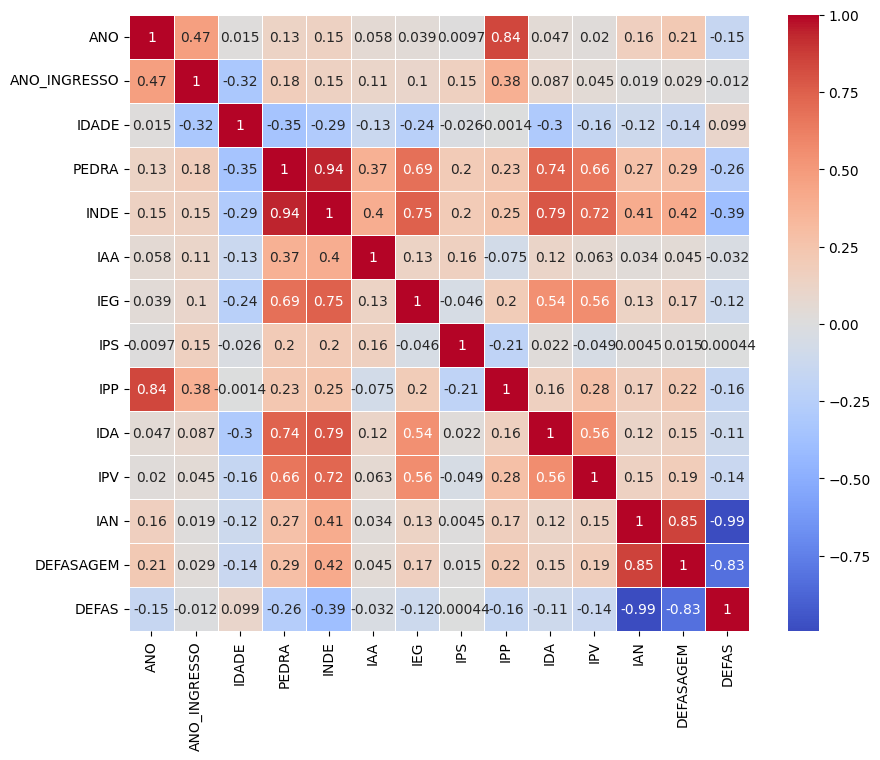

In [53]:
df_num = df.select_dtypes(include=['number'])

# Calcula a matriz de correlação só com colunas numéricas
matriz_correlacao = df_num.corr()


fig, axes = plt.subplots(figsize=(10, 8))
sns.heatmap(data=matriz_correlacao, cmap='coolwarm', annot=True, linewidths=0.5, ax=axes)
plt.show()

## 1. Adequação de nível (IAN)

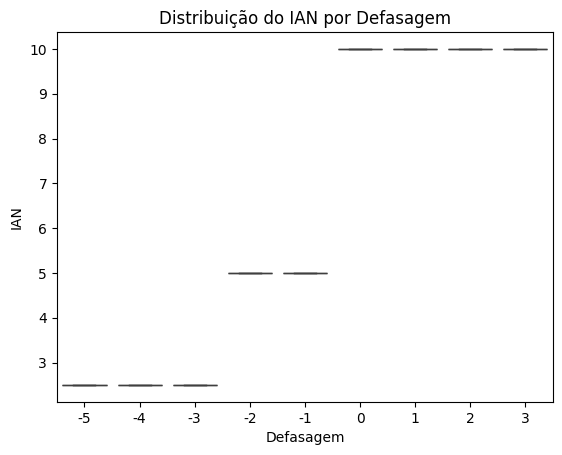

In [54]:
sns.boxplot(x="DEFASAGEM", y="IAN", data=df)

plt.title("Distribuição do IAN por Defasagem")
plt.xlabel("Defasagem")
plt.ylabel("IAN")
plt.show()

- é possível observar que o IAN está altamente correlacionado com a defasagem, alunos que possuem defasagem tem nota menor ou igual a 5 no IAN, e alunos que não estão defasados, tem nota 10

In [55]:
# verificar a quantidade de alunos em cada nivel de IAN
contagem = df.groupby(['ANO', 'IAN']).size().unstack(fill_value=0)
print(contagem)

IAN   2.5   5.0   10.0
ANO                   
2022    28   573   259
2023    14   538   462
2024     3   531   520


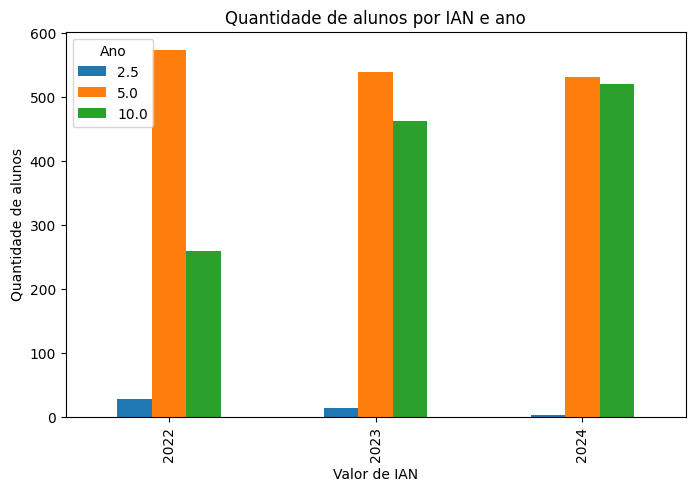

In [56]:
# gráfico para verificar a evolução dos alunos em relação ao IAN ao longo dos anos
contagem.plot(kind="bar", figsize=(8,5))

plt.title("Quantidade de alunos por IAN e ano")
plt.xlabel("Valor de IAN")
plt.ylabel("Quantidade de alunos")

plt.legend(title="Ano")

plt.show()

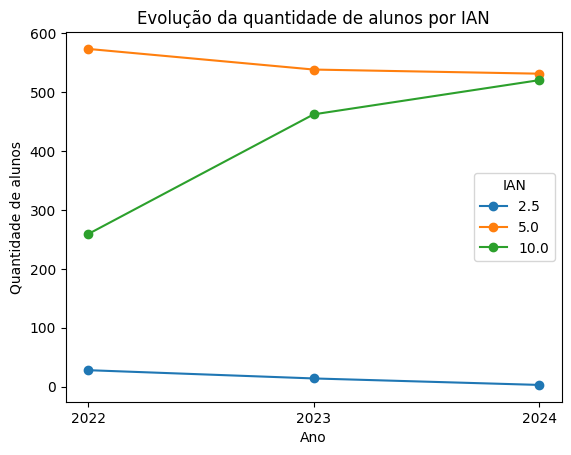

In [57]:
contagem.plot(marker='o')

plt.title("Evolução da quantidade de alunos por IAN")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")

plt.xticks([2022, 2023, 2024])  # força apenas esses valores

plt.show()


- através das análises é possível observar que o número de alunos que estão severamente defasados é pequeno em todos os anos do estudo, ficando abaixo de 30

- o número de alunos moderadamente defasados é maior que os demais, e se mantém estável ao longo dos 3 anos de estudo

- o número de alunos que não estão defasados aumenta siginificativamente ao longo dos 3 anos, chegando ao mesmo patamar de alunos com defasagem moderada em 2024

- portanto, o perfil de defasagem evolui positivamente entre 2022 e 2024, com aumento do número de alunos sem defasagem, que dobra de 259 em 2022 para 520 alunos em 2024

## 2. Desempenho acadêmico (IDA)

In [58]:
df['IDA'].describe()

,IDA
count,2851.000000
mean,6.375395
std,1.956744
min,0.000000
25%,5.100000
50%,6.666667
75%,7.833333
max,10.000000


In [59]:
# calcular a média de IDA por ano
media_ida = df.groupby('ANO')['IDA'].mean()
media_ida

,IDA
ANO,
2022,6.092907
2023,6.663394
2024,6.349858


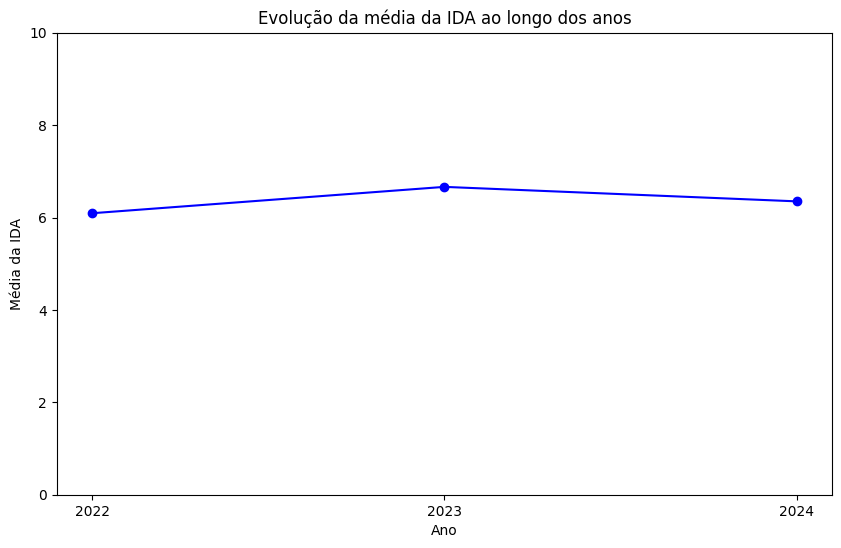

In [60]:
# visualização da evolução da média de IDA ao longo dos anos
plt.figure(figsize=(10, 6))

plt.plot(media_ida.index, media_ida.values, marker='o', linestyle='-', color='b')

plt.title('Evolução da média da IDA ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Média da IDA')

plt.ylim(0,10)
plt.xticks(media_ida.index)

plt.show()

- Através do gráfico acima é possível observar que a média do desempenho acadêmico se manteve estável entre 2022 e 2024

## 3. Engajamento nas atividades (IEG)

In [61]:
df[['IEG', 'IDA', 'IPV']].describe()

,IEG,IDA,IPV
count,2852.000000,2851.000000,2852.000000
mean,8.229869,6.375395,7.545476
std,1.567966,1.956744,1.084347
min,0.000000,0.000000,2.500000
25%,7.500000,5.100000,6.984000
50%,8.659361,6.666667,7.583000
75%,9.400000,7.833333,8.255000
max,10.000000,10.000000,10.010000


<Axes: xlabel='IEG', ylabel='IDA'>

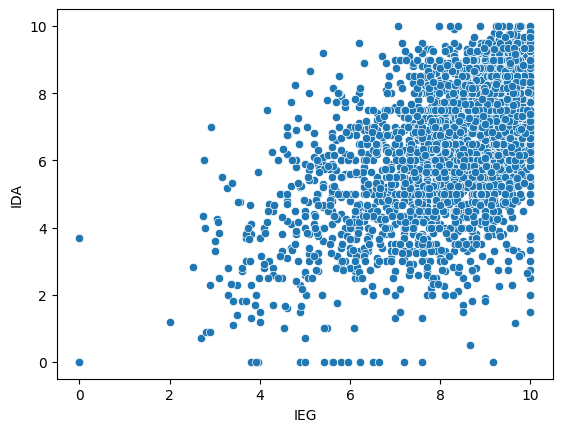

In [62]:
# visualização da dispersão entre IEG e IDA
sns.scatterplot(data=df, x="IEG", y="IDA")

<Axes: xlabel='IEG', ylabel='IPV'>

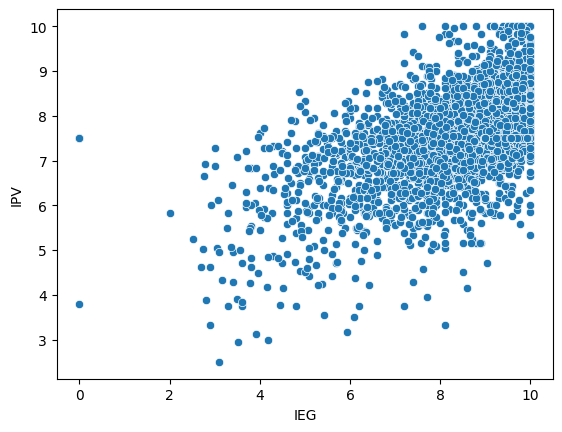

In [63]:
# visualização da dispersão entre IEG e IPV
sns.scatterplot(data=df, x="IEG", y="IPV")

In [64]:
# correlação entre as variáveis
df[['IEG','IDA','IPV']].corr()

,IEG,IDA,IPV
IEG,1.000000,0.543253,0.558200
IDA,0.543253,1.000000,0.557072
IPV,0.558200,0.557072,1.000000


In [65]:
# correlação de Pearson
from scipy.stats import pearsonr

df_clean = df[['IEG','IDA', 'IPV']].dropna()
pearsonr(df_clean["IEG"], df_clean["IDA"])

PearsonRResult(statistic=np.float64(0.5432528561632598), pvalue=np.float64(1.1914037639689393e-218))

In [66]:
pearsonr(df_clean["IEG"], df_clean["IPV"])

PearsonRResult(statistic=np.float64(0.5582820307578932), pvalue=np.float64(2.2952517219855003e-233))

- a partir das análises de correlação realizadas, tanto por meio do mapa de calor da matriz de correlação quanto pelo coeficiente de correlação de Pearson, foi possível identificar a existência de uma correlação positiva moderada entre o indicador de engajamento dos alunos (IEG) e os indicadores de desempenho acadêmico (IDA) e de ponto de virada (IPV)

- essa relação também pode ser observada nos gráficos de dispersão, nos quais se verifica uma tendência de crescimento conjunto entre as variáveis. À medida que os valores do IEG aumentam, os valores de IDA e IPV tendem a apresentar aumento, indicando que níveis mais elevados de engajamento estão associados a melhores resultados nesses indicadores

- essa análise sugere que o engajamento dos alunos pode ser relacionado com seu desempenho acadêmico

## 4. Autoavaliação (IAA)

In [67]:
df[['IAA','IDA','IEG']].describe()

,IAA,IDA,IEG
count,2865.000000,2851.000000,2852.000000
mean,7.918225,6.375395,8.229869
std,2.626209,1.956744,1.567966
min,0.000000,0.000000,0.000000
25%,7.900000,5.100000,7.500000
50%,8.751000,6.666667,8.659361
75%,9.500000,7.833333,9.400000
max,10.002000,10.000000,10.000000


<Axes: xlabel='IAA', ylabel='IDA'>

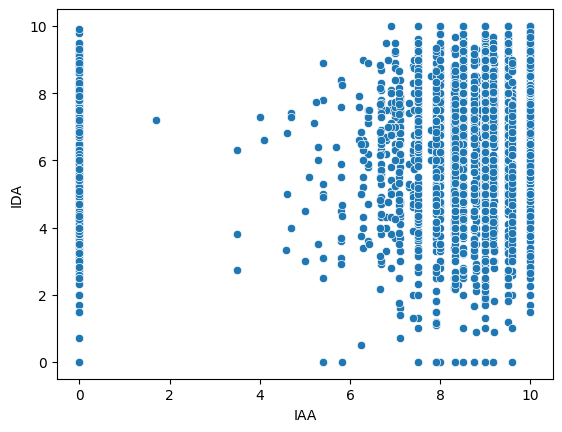

In [68]:
sns.scatterplot(data=df, x="IAA", y="IDA")

<Axes: xlabel='IAA', ylabel='IEG'>

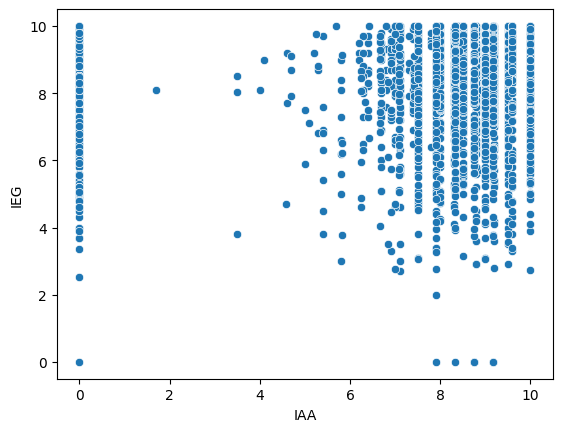

In [69]:
sns.scatterplot(data=df, x="IAA", y="IEG")

In [70]:
# correlação de Pearson IAA x IDA

df_clean_iaa = df[['IAA','IDA', 'IEG']].dropna()
pearsonr(df_clean_iaa['IAA'], df_clean_iaa['IDA'])

PearsonRResult(statistic=np.float64(0.11524053422613789), pvalue=np.float64(6.781176594626001e-10))

In [71]:
# correlação de Pearson IAA x IEG
pearsonr(df_clean_iaa['IAA'], df_clean_iaa['IEG'])

PearsonRResult(statistic=np.float64(0.13132358072531247), pvalue=np.float64(1.930404976648063e-12))

- analisando o resultado do coeficiente de correlação de Pearson, é possível observar que existe uma correlação muito fraca entre o indicador IAA e os indicadores de desempenho (IDA) e engajamento (IEG), indicando que a percepção dos alunos sobre si mesmos não tem associação com seu desempenho real

- pelo gráfico de dispersão, pode-se observar uma leve tendência do aluno que se esforça e tem maior engajamento a se autoavaliar melhor

## 5. Aspectos Psicossociais (IPS)

In [72]:
# identificar se ocorreu queda
df_ips = df.sort_values(['RA','ANO'])

# definir um patamar de queda de 1,5 pontos
df_ips['queda_IDA'] = df_ips.groupby('RA')['IDA'].diff() < -1.5
df_ips['queda_IEG'] = df_ips.groupby('RA')['IEG'].diff() < -1.5

In [73]:
df_ips.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM,DEFAS,queda_IDA,queda_IEG
0,RA-1,2022,2016,19,1.0,5.7830,8.3,4.1,5.60,0.00,4.0,7.278,5.0,-1,1,False,False
1855,RA-1,2023,2016,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0,0,False,False
9,RA-10,2022,2021,18,1.0,5.7840,8.3,5.2,5.00,0.00,4.1,7.056,5.0,-1,1,False,False
99,RA-100,2022,2019,13,3.0,7.6180,8.8,7.8,5.00,0.00,7.6,7.250,10.0,1,0,False,False
1072,RA-1000,2023,2023,8,3.0,7.9162,8.5,9.4,3.77,6.25,7.0,8.920,10.0,0,0,False,False


In [74]:
df_ips['IPS_lag1'] = df_ips.groupby('RA')['IPS'].shift(1)

In [75]:
df_ips.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM,DEFAS,queda_IDA,queda_IEG,IPS_lag1
0,RA-1,2022,2016,19,1.0,5.7830,8.3,4.1,5.60,0.00,4.0,7.278,5.0,-1,1,False,False,NaN
1855,RA-1,2023,2016,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0,0,False,False,5.6
9,RA-10,2022,2021,18,1.0,5.7840,8.3,5.2,5.00,0.00,4.1,7.056,5.0,-1,1,False,False,NaN
99,RA-100,2022,2019,13,3.0,7.6180,8.8,7.8,5.00,0.00,7.6,7.250,10.0,1,0,False,False,NaN
1072,RA-1000,2023,2023,8,3.0,7.9162,8.5,9.4,3.77,6.25,7.0,8.920,10.0,0,0,False,False,NaN


In [76]:
# verifica se o IPS anterior é diferente entre quem teve queda e quem não teve
df_ips.groupby('queda_IDA')['IPS_lag1'].mean()

,IPS_lag1
queda_IDA,
False,6.046641
True,5.601992


In [77]:
df_ips.groupby('queda_IEG')['IPS_lag1'].mean()

,IPS_lag1
queda_IEG,
False,6.110597
True,5.158137


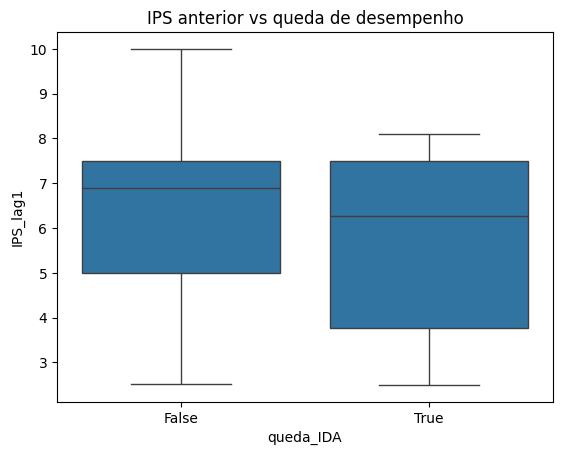

In [78]:
sns.boxplot(x='queda_IDA', y='IPS_lag1', data=df_ips)

plt.title("IPS anterior vs queda de desempenho")
plt.show()

In [79]:
df_ips['queda_IDA_num'] = df_ips['queda_IDA'].astype(int)
df_ips['queda_IEG_num'] = df_ips['queda_IEG'].astype(int)

df_ips[['IPS_lag1','queda_IDA_num','queda_IEG_num']].corr()

,IPS_lag1,queda_IDA_num,queda_IEG_num
IPS_lag1,1.000000,-0.091835,-0.181300
queda_IDA_num,-0.091835,1.000000,0.337875
queda_IEG_num,-0.181300,0.337875,1.000000


- pode-se observar que há uma correlação negativa fraca entre o IPS do ano anterior e as quedas de IEG e IDA

- mesmo fraca, essa correlação sugere que padrões psicossociais baixos podem preceder queda no engajamento e no desempenho academico


## 6. Aspectos Psicopedagógicos (IPP)

In [80]:
# confere se há correlação entre IPP e a defasagem IAN
df[['IPP','IAN']].corr()

,IPP,IAN
IPP,1.000000,0.171437
IAN,0.171437,1.000000


In [81]:
# compara o IPP entre alunos com e sem defasagem
df.groupby('DEFAS')['IPP'].mean()

,IPP
DEFAS,
0,5.974123
1,4.794161


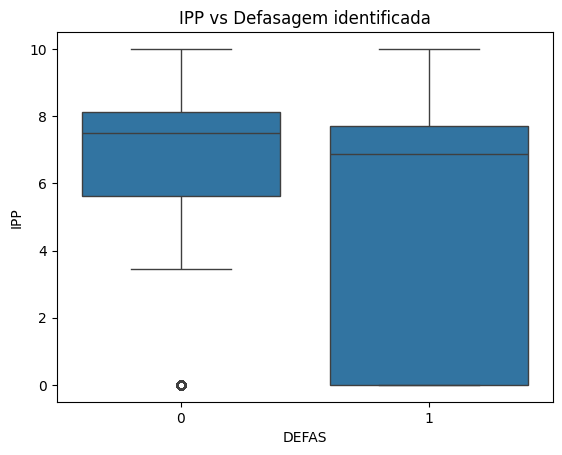

In [82]:
sns.boxplot(x='DEFAS', y='IPP', data=df)

plt.title("IPP vs Defasagem identificada")
plt.show()

- é possível observar que os alunos com defasagem apresentam, em média, valores de IPP menores do que os alunos sem defasagem

- esse resultado sugere que as avaliações psicopedagógicas tendem a refletir dificuldades associadas a defasagem academica

- o bloxplot mostra que há uma grande dispersão de IPP entre os alunos que apresentam defasagem, entre esses alunos existem casos com dificuldades psicopedagógicas mais severas - o que não acontece em alunos que não estão defasados

## 7. Ponto de Virada (IPV)

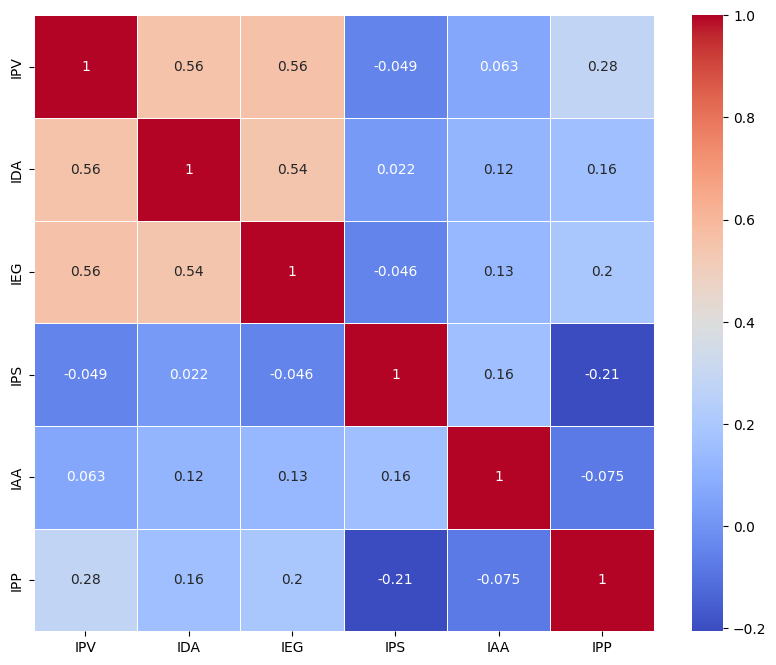

In [83]:
# Calcula a matriz de correlação entre os indicadores
df_teste = df[['IPV', 'IDA', 'IEG', 'IPS', 'IAA', 'IPP']]
matriz_correlacao = df_teste.corr()


fig, axes = plt.subplots(figsize=(10, 8))
sns.heatmap(data=matriz_correlacao, cmap='coolwarm', annot=True, linewidths=0.5, ax=axes)
plt.show()

- de acordo com a matriz de correlação, os comportamentos que mais influenciam o IPV são o engajamento e o desempenho acadêmico

- os fatores emocionais não possuem influência sobre o ponto de virada

## 8. Multidimensionalidade dos indicadores

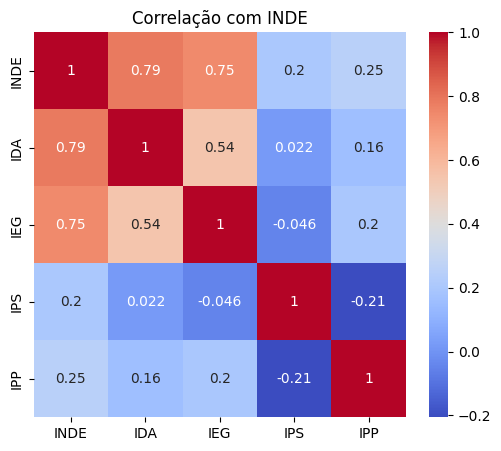

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['INDE','IDA','IEG','IPS','IPP']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlação com INDE")
plt.show()

- a matriz de correlação indica que os indicadores IDA (0.79) e IEG (0.75) apresentam as maiores correlações positivas com o desempenho global (INDE), sugerindo que fatores relacionados à dedicação e engajamento acadêmico são os principais determinantes do desempenho dos alunos

In [85]:
# análise de regressão de múltiplas variáveis para medir efeito combinado

import statsmodels.api as sm

cols = ['IDA','IEG','IPS','IPP','INDE']

df_model = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

X = df_model[['IDA','IEG','IPS','IPP']]
y = df_model['INDE']

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   INDE   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     3212.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:50:33   Log-Likelihood:                -1581.8
No. Observations:                2845   AIC:                             3174.
Df Residuals:                    2840   BIC:                             3203.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2476      0.053     42.599      0.0

- a análise de regressão múltipla confirmar o que pode ser observado na matriz de correlação, os comportamentos que mais influenciam no ponto de virada (IPV) do aluno, são o engajamento (IEG) e desempenho (IDA)

## 10. Efetividade do programa

In [86]:
# média dos indicadores por fase
df_filtrado = df[df['PEDRA'] != 0]
indicadores = ['INDE','IDA','IEG','IPS','IPP','IPV','IAA']

df_filtrado.groupby('PEDRA')[indicadores].mean()

,INDE,IDA,IEG,IPS,IPP,IPV,IAA
PEDRA,,,,,,,
1.0,5.368562,3.461973,5.606515,5.790585,3.814939,6.057199,5.755411
2.0,6.591564,5.264124,7.585811,5.993662,4.693929,7.032720,7.234510
3.0,7.524473,6.807292,8.675153,6.305415,5.241020,7.737460,8.312339
4.0,8.439701,8.180766,9.384573,6.836937,6.597126,8.455660,9.021080


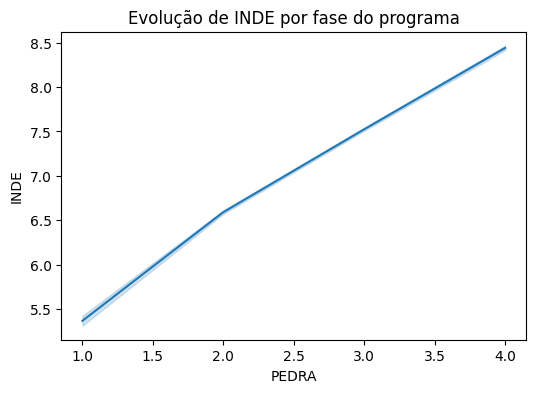

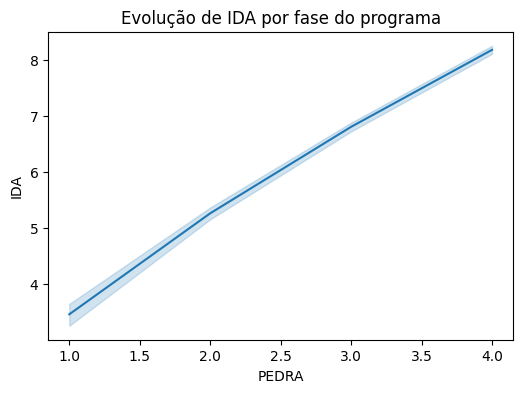

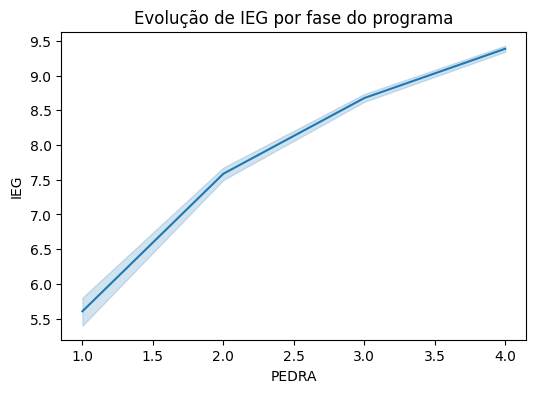

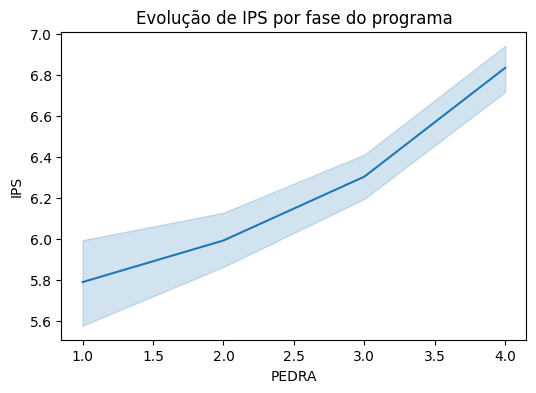

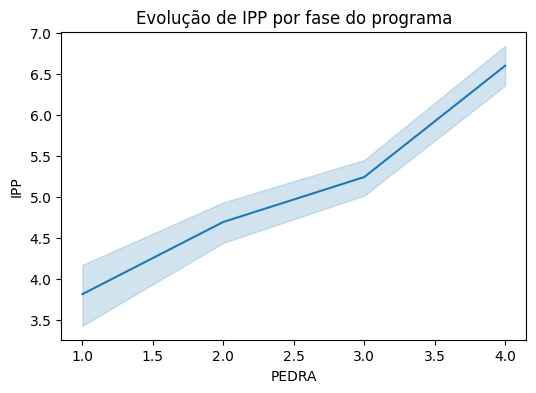

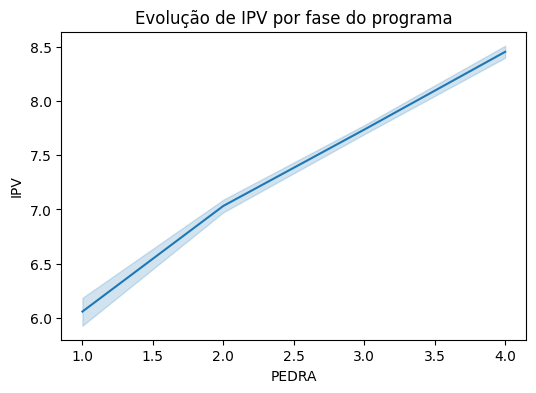

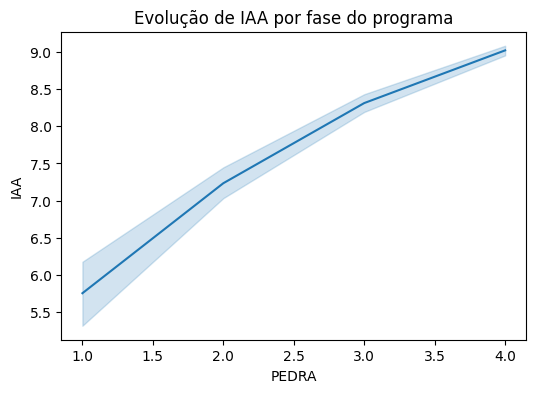

In [87]:
for col in indicadores:
    plt.figure(figsize=(6,4))
    sns.lineplot(data=df_filtrado, x='PEDRA', y=col, estimator='mean')
    plt.title(f'Evolução de {col} por fase do programa')
    plt.show()

- a análise da evolução dos indicadores ao longo das fases do programa indica tendência de melhora progressiva no desempenho dos alunos em todos os indicadores

# Modelo Preditivo

In [88]:
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

In [89]:
# ordena o df por ano e RA
df = df.sort_values(["RA", "ANO"]).reset_index(drop=True)

definição da variável target:

- o objetivo é verificar o risco antes da defasagem acontecer, portanto, é necessário criar uma variável futura que mostra se o aluno entrou em defasagem no próximo ano ou não

Construímos um modelo supervisionado de classificação para prever a probabilidade de um aluno entrar em risco de defasagem no período seguinte, a partir de seus indicadores atuais e do seu histórico recente. O modelo permite atuação preventiva da Passos Mágicos, priorizando alunos com maior probabilidade de deterioração educacional.

In [90]:
# Target: risco de defasagem no próximo ano
df["TARGET_RISCO"] = df.groupby("RA")["DEFAS"].shift(-1)
df["ANO_ALVO"] = df.groupby("RA")["ANO"].shift(-1)

In [91]:
# Manter apenas linhas que têm futuro observado
model_df = df[df["TARGET_RISCO"].notna()].copy()

In [92]:
# Garantir target binário inteiro
model_df["TARGET_RISCO"] = model_df["TARGET_RISCO"].astype(int)

In [93]:
model_df.head()

,RA,ANO,ANO_INGRESSO,IDADE,PEDRA,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,DEFASAGEM,DEFAS,TARGET_RISCO,ANO_ALVO
0,RA-1,2022,2016,19,1.0,5.7830,8.3,4.1,5.60,0.00,4.0,7.278,5.0,-1,1,0,2023.0
4,RA-1000,2023,2023,8,3.0,7.9162,8.5,9.4,3.77,6.25,7.0,8.920,10.0,0,0,0,2024.0
6,RA-1001,2023,2023,9,4.0,8.1162,9.0,9.1,7.52,7.50,7.8,9.170,5.0,-1,1,1,2024.0
8,RA-1002,2023,2023,9,3.0,7.9012,9.0,9.7,7.52,6.25,7.0,8.920,5.0,-1,1,1,2024.0
10,RA-1003,2023,2023,8,3.0,7.6522,9.0,8.5,7.52,7.50,4.0,8.750,10.0,0,0,1,2024.0


In [94]:
anos_disponiveis = sorted(model_df["ANO"].dropna().unique())
print("Anos de origem disponíveis:", anos_disponiveis)

ano_teste = anos_disponiveis[-1]

train_idx = model_df["ANO"] < ano_teste
test_idx = model_df["ANO"] == ano_teste

train_df = model_df.loc[train_idx].copy()
test_df = model_df.loc[test_idx].copy()

print("Ano de teste:", ano_teste)
print("Treino:", train_df.shape)
print("Teste:", test_df.shape)
print("Taxa de risco treino:", train_df["TARGET_RISCO"].mean())
print("Taxa de risco teste:", test_df["TARGET_RISCO"].mean())

Anos de origem disponíveis: [np.int64(2022), np.int64(2023)]
Ano de teste: 2023
Treino: (604, 17)
Teste: (692, 17)
Taxa de risco treino: 0.6076158940397351
Taxa de risco teste: 0.44508670520231214


In [95]:
def treinar_e_avaliar_modelo(train_df, test_df, feature_cols, nome_modelo="modelo"):
    X_train = train_df[feature_cols].copy()
    y_train = train_df["TARGET_RISCO"].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df["TARGET_RISCO"].copy()

    # Remover colunas totalmente vazias no treino
    all_nan_cols = X_train.columns[X_train.isna().all()].tolist()
    if len(all_nan_cols) > 0:
        print(f"\n[{nome_modelo}] Colunas removidas por estarem 100% vazias no treino:")
        print(all_nan_cols)

    X_train = X_train.drop(columns=all_nan_cols)
    X_test = X_test.drop(columns=all_nan_cols)

    numeric_features = X_train.columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", rf)
    ])

    calibrated_model = CalibratedClassifierCV(
        estimator=pipeline,
        method="sigmoid",
        cv=3
    )

    calibrated_model.fit(X_train, y_train)

    proba_test = calibrated_model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, proba_test)
    pr_auc = average_precision_score(y_test, proba_test)

    # Escolha de threshold orientado a recall
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)

    metricas_threshold = pd.DataFrame({
        "threshold": np.append(thresholds, 1.0),
        "precision": precisions,
        "recall": recalls
    })

    candidatos = metricas_threshold[metricas_threshold["recall"] >= 0.75].copy()

    if len(candidatos) > 0:
        melhor = candidatos.sort_values(["precision", "recall"], ascending=False).iloc[0]
        threshold_escolhido = float(melhor["threshold"])
    else:
        threshold_escolhido = 0.50

    pred_test = (proba_test >= threshold_escolhido).astype(int)

    print(f"\n=== {nome_modelo.upper()} ===")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Threshold escolhido: {threshold_escolhido:.4f}")
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, pred_test))
    print("\nRelatório de classificação:")
    print(classification_report(y_test, pred_test, digits=4))

    # Resultado gerencial
    resultado = test_df[["RA", "ANO", "ANO_ALVO"]].copy()
    resultado["PROB_RISCO"] = proba_test
    resultado["PRED_RISCO"] = pred_test
    resultado["TARGET_REAL"] = y_test.values

    resultado["FAIXA_RISCO"] = pd.cut(
        resultado["PROB_RISCO"],
        bins=[0, 0.30, 0.60, 1.0],
        labels=["Baixo", "Médio", "Alto"],
        include_lowest=True
    )

    resultado = resultado.sort_values("PROB_RISCO", ascending=False)

    # Importância por permutação
    perm = permutation_importance(
        calibrated_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="average_precision"
    )

    importancias = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    return {
        "model": calibrated_model,
        "X_train_cols": X_train.columns.tolist(),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "threshold": threshold_escolhido,
        "resultado": resultado,
        "importancias": importancias
    }

In [96]:
features_baseline = [
    "ANO", "ANO_INGRESSO", "IDADE", "PEDRA",
    "INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN",
    "DEFASAGEM", "DEFAS",
    "TEMPO_PROGRAMA", "IDADE_INGRESSO_APROX"
]

features_baseline = [f for f in features_baseline if f in model_df.columns]

resultado_baseline = treinar_e_avaliar_modelo(
    train_df=train_df,
    test_df=test_df,
    feature_cols=features_baseline,
    nome_modelo="prev_defasagem"
)


=== PREV_DEFASAGEM ===
ROC-AUC: 0.8017
PR-AUC: 0.7882
Threshold escolhido: 0.4539

Matriz de confusão:
[[244 140]
 [ 77 231]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.7601    0.6354    0.6922       384
           1     0.6226    0.7500    0.6804       308

    accuracy                         0.6864       692
   macro avg     0.6914    0.6927    0.6863       692
weighted avg     0.6989    0.6864    0.6870       692



O modelo apresentou desempenho consistente, com ROC-AUC de 0,80 e PR-AUC de 0,78, indicando boa capacidade de discriminação e priorização de alunos em risco. O recall da classe de risco foi de 75%, o que demonstra que o modelo consegue identificar a maioria dos alunos que efetivamente entrarão em defasagem. Embora haja presença de falsos positivos, essa característica é aceitável no contexto de intervenção social, pois prioriza a redução de falsos negativos e permite atuação preventiva mais abrangente. Dessa forma, o modelo é considerado adequado para uso como sistema de alerta precoce na Passos Mágicos.

In [97]:
prev_defasagem = resultado_baseline

In [98]:
joblib.dump(prev_defasagem["model"], "modelo_risco_defasagem.pkl")
joblib.dump(prev_defasagem["X_train_cols"], "features_modelo.pkl")

['features_modelo.pkl']

# Streamlit

In [99]:
!pip install streamlit plotly
!pip install scikit-learn --upgrade

In [100]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

st.set_page_config(
    page_title="Passos Magicos - Predicao de Risco",
    page_icon="🎓",
    layout="wide"
)

@st.cache_resource
def carregar_modelo():
    modelo   = joblib.load("modelo_risco_defasagem.pkl")
    features = joblib.load("features_modelo.pkl")
    return modelo, features

modelo, features_modelo = carregar_modelo()

THRESHOLD = 0.4539

def classificar_faixa(prob):
    if prob < 0.30:
        return "Baixo", "#2ecc71"
    elif prob < 0.60:
        return "Medio", "#f39c12"
    return "Alto", "#e74c3c"

def preparar_entrada(df, features_esperadas):
    df = df.copy()
    df.columns = [c.strip().upper() for c in df.columns]
    for col in features_esperadas:
        if col not in df.columns:
            df[col] = np.nan
    df = df[features_esperadas].copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def gauge_risco(prob, faixa, cor):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=round(prob * 100, 1),
        number={"suffix": "%", "font": {"size": 36, "color": cor}},
        gauge={
            "axis": {"range": [0, 100]},
            "bar": {"color": cor},
            "steps": [
                {"range": [0, 30],   "color": "#d5f5e3"},
                {"range": [30, 60],  "color": "#fdebd0"},
                {"range": [60, 100], "color": "#fadbd8"},
            ],
            "threshold": {
                "line": {"color": "black", "width": 2},
                "thickness": 0.75,
                "value": THRESHOLD * 100
            }
        },
        title={"text": "Faixa: " + faixa, "font": {"size": 16}}
    ))
    fig.update_layout(height=260, margin=dict(t=40, b=10, l=20, r=20))
    return fig

INDICADORES = {
    "INDE":      "Indice de Desenvolvimento Educacional - nota global do aluno.",
    "IAA":       "Indice de Autoavaliacao - como o aluno percebe seu proprio desempenho.",
    "IEG":       "Indice de Engajamento - frequencia e participacao nas atividades.",
    "IPS":       "Indice Psicossocial - aspectos emocionais e sociais avaliados pela equipe.",
    "IPP":       "Indice Psicopedagogico - avaliacao das dificuldades de aprendizagem.",
    "IDA":       "Indice de Desempenho Academico - resultado nas avaliacoes escolares.",
    "IPV":       "Indice do Ponto de Virada - marco de transformacao no programa.",
    "IAN":       "Indice de Adequacao de Nivel - se o aluno esta na fase correta para sua idade.",
    "PEDRA":     "Fase do programa: Quartzo (1), Agata (2), Ametista (3) ou Topazio (4).",
    "DEFASAGEM": "Diferenca entre a fase atual e a ideal. Valores negativos indicam defasagem.",
    "DEFAS":     "Flag binaria: 1 se o aluno esta defasado, 0 caso contrario.",
}

st.title("🎓 Passos Magicos - Predicao de Risco de Defasagem")
st.markdown("Sistema preditivo para identificar alunos em risco de defasagem escolar.")

aba1, aba2, aba3 = st.tabs(["Predicao Individual", "Predicao em Lote", "Sobre os Indicadores"])

with aba1:
    st.markdown("##### Preencha os indicadores do aluno")
    col1, col2, col3, col4 = st.columns(4)

    with col1:
        ano          = st.number_input("ANO",          min_value=2020, max_value=2035, value=2024)
        ano_ingresso = st.number_input("ANO_INGRESSO", min_value=2010, max_value=2035, value=2023)
        idade        = st.number_input("IDADE",        min_value=5,    max_value=30,   value=10)
        pedra        = st.number_input("PEDRA",        min_value=0.0,  max_value=10.0, value=3.0)

    with col2:
        inde = st.number_input("INDE", min_value=0.0, max_value=10.0, value=7.50, step=0.01)
        iaa  = st.number_input("IAA",  min_value=0.0, max_value=10.0, value=8.00, step=0.01)
        ieg  = st.number_input("IEG",  min_value=0.0, max_value=10.0, value=8.00, step=0.01)
        ips  = st.number_input("IPS",  min_value=0.0, max_value=10.0, value=8.00, step=0.01)

    with col3:
        ipp = st.number_input("IPP", min_value=0.0, max_value=10.0, value=7.00, step=0.01)
        ida = st.number_input("IDA", min_value=0.0, max_value=10.0, value=7.00, step=0.01)
        ipv = st.number_input("IPV", min_value=0.0, max_value=10.0, value=7.00, step=0.01)
        ian = st.number_input("IAN", min_value=0.0, max_value=10.0, value=7.00, step=0.01)

    with col4:
        defasagem = st.number_input("DEFASAGEM", min_value=-20.0, max_value=20.0, value=0.0, step=0.1)
        defas     = st.selectbox("DEFAS", options=[0, 1], index=0)

    tempo_programa       = ano - ano_ingresso
    idade_ingresso_aprox = idade - tempo_programa

    st.markdown(f"**Tempo no programa:** {tempo_programa} ano(s) | **Idade de ingresso aproximada:** {idade_ingresso_aprox} anos")

    if st.button("Calcular risco", type="primary"):
        entrada = pd.DataFrame([{
            "ANO": ano, "ANO_INGRESSO": ano_ingresso, "IDADE": idade,
            "PEDRA": pedra, "INDE": inde, "IAA": iaa, "IEG": ieg, "IPS": ips,
            "IPP": ipp, "IDA": ida, "IPV": ipv, "IAN": ian,
            "DEFASAGEM": defasagem, "DEFAS": defas,
            "TEMPO_PROGRAMA": tempo_programa, "IDADE_INGRESSO_APROX": idade_ingresso_aprox
        }])

        entrada_modelo = preparar_entrada(entrada, features_modelo)
        prob  = float(modelo.predict_proba(entrada_modelo)[0, 1])
        pred  = int(prob >= THRESHOLD)
        faixa, cor = classificar_faixa(prob)

        st.divider()
        g_col, r_col = st.columns([1, 1])

        with g_col:
            st.plotly_chart(gauge_risco(prob, faixa, cor), use_container_width=True)

        with r_col:
            st.metric("Probabilidade de risco", f"{prob:.1%}")
            st.metric("Classificacao", "Risco" if pred == 1 else "Sem risco")
            st.metric("Faixa", faixa)
            if pred == 1:
                st.warning("O aluno foi sinalizado como prioritario para acompanhamento preventivo.")
            else:
                st.success("O aluno nao apresentou sinal critico no limiar operacional atual.")

with aba2:
    st.markdown("##### Faca upload de uma planilha com multiplos alunos")
    st.markdown(
        "A planilha deve conter as colunas: "
        "`ANO, ANO_INGRESSO, IDADE, PEDRA, INDE, IAA, IEG, IPS, IPP, IDA, IPV, IAN, DEFASAGEM, DEFAS`"
    )

    arquivo = st.file_uploader("Upload da planilha (.xlsx ou .csv)", type=["xlsx", "csv"])

    if arquivo:
        try:
            if arquivo.name.endswith(".csv"):
                df_lote = pd.read_csv(arquivo)
            else:
                df_lote = pd.read_excel(arquivo)

            df_lote.columns = [c.strip().upper() for c in df_lote.columns]
            entrada_lote = preparar_entrada(df_lote, features_modelo)
            probas = modelo.predict_proba(entrada_lote)[:, 1]
            preds  = (probas >= THRESHOLD).astype(int)
            faixas = [classificar_faixa(p)[0] for p in probas]

            df_resultado = df_lote.copy()
            df_resultado["PROB_RISCO"]  = (probas * 100).round(1)
            df_resultado["PRED_RISCO"]  = ["Risco" if p == 1 else "Sem risco" for p in preds]
            df_resultado["FAIXA_RISCO"] = faixas

            st.success(f"{len(df_resultado)} alunos processados com sucesso.")

            r1, r2, r3 = st.columns(3)
            r1.metric("Total de alunos", len(df_resultado))
            r2.metric("Em risco", int(preds.sum()))
            r3.metric("Sem risco", int((preds == 0).sum()))

            st.dataframe(
                df_resultado[["PROB_RISCO", "PRED_RISCO", "FAIXA_RISCO"] + features_modelo],
                use_container_width=True
            )

            csv = df_resultado.to_csv(index=False).encode("utf-8")
            st.download_button(
                "Baixar resultado (.csv)",
                data=csv,
                file_name="resultado_risco.csv",
                mime="text/csv"
            )
        except Exception as e:
            st.error(f"Erro ao processar o arquivo: {e}")

with aba3:
    st.markdown("##### O que significa cada indicador?")
    st.markdown(
        "Os indicadores abaixo fazem parte do sistema de avaliacao da "
        "Associacao Passos Magicos, utilizado para acompanhar o desenvolvimento "
        "educacional e socioemocional dos alunos."
    )
    for sigla, descricao in INDICADORES.items():
        st.markdown(f"**{sigla}** — {descricao}")

st.divider()
st.markdown(
    "<p style='text-align:center; color:gray; font-size:0.8rem;'>"
    "Datathon - Data Analytics - FIAP - 2026"
    "</p>",
    unsafe_allow_html=True
)

"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code.strip())

print("app.py criado com sucesso.")

app.py criado com sucesso.


In [101]:
req = """pandas
numpy
scikit-learn
joblib
streamlit==1.43.0
altair>=5.0.0
plotly
openpyxl
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(req)

print("requirements.txt criado com sucesso.")

requirements.txt criado com sucesso.


In [102]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("modelo_risco_defasagem.pkl")
files.download("features_modelo.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>